# Feature Engineering & Statistical Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

In [2]:
DATA_DIR = Path('../r4.1')
ART_DIR = Path('../artifacts')
ART_DIR.mkdir(exist_ok=True)

## Load raw event tables

Parse the timestamp and attach the calendar fields needed for the behavioural features. After-hours is defined as before 07:00 or from 19:00 onward, matching the CERT note that after-hours activity is a key indicator.

In [3]:
def add_time_fields(df):
    df['date'] = pd.to_datetime(df['date'])
    df['hour'] = df['date'].dt.hour
    df['weekday'] = df['date'].dt.weekday
    df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
    df['is_after_hours'] = ((df['hour'] < 7) | (df['hour'] >= 19)).astype(int)
    return df

In [4]:
logon = add_time_fields(pd.read_csv(DATA_DIR / 'logon.csv'))
logon.shape

(899118, 9)

In [5]:
device = add_time_fields(pd.read_csv(DATA_DIR / 'device.csv'))
device.shape

(437168, 9)

In [6]:
file = add_time_fields(pd.read_csv(DATA_DIR / 'file.csv'))
file.shape

(414556, 10)

In [7]:
psych = pd.read_csv(DATA_DIR / 'psychometric.csv')
psych.shape

(1000, 7)

## Logon features

Authentication behaviour: how often a user logs on, the typical hour and its spread, and how much of that activity falls on weekends, after hours, or across many machines.

In [8]:
gl = logon.groupby('user')
logon_feat = pd.DataFrame({
    'total_logons': gl.size(),
    'avg_logon_hour': gl['hour'].mean(),
    'std_logon_hour': gl['hour'].std(),
    'weekend_logons': gl['is_weekend'].sum(),
    'after_hours_logons': gl['is_after_hours'].sum(),
    'unique_pcs_logon': gl['pc'].nunique(),
})
logon_feat.head()

,total_logons,avg_logon_hour,std_logon_hour,weekend_logons,after_hours_logons,unique_pcs_logon
user,,,,,,
AAB0224,2718,11.998160,7.347492,0,1533,625
AAD0986,692,12.000000,4.002893,0,0,1
AAH0706,692,11.511561,4.516076,0,0,1
AAR0566,692,11.534682,5.034205,0,163,1
AAT0419,969,12.077399,3.862994,0,0,1


## Device features

USB usage: total connect/disconnect volume, number of distinct machines used, typical hour, and after-hours device events (the CERT documentation flags after-hours thumb-drive use specifically).

In [9]:
gd = device.groupby('user')
device_feat = pd.DataFrame({
    'total_device_activities': gd.size(),
    'device_connects': gd['activity'].apply(lambda s: (s == 'Connect').sum()),
    'device_disconnects': gd['activity'].apply(lambda s: (s == 'Disconnect').sum()),
    'unique_pcs_device': gd['pc'].nunique(),
    'avg_device_hour': gd['hour'].mean(),
    'after_hours_device': gd['is_after_hours'].sum(),
})
device_feat.head()


,total_device_activities,device_connects,device_disconnects,unique_pcs_device,avg_device_hour,after_hours_device
user,,,,,,
ABB0427,34,17,17,1,15.088235,34
ACM0931,840,423,417,1,11.403571,8
ACT0844,723,363,360,1,12.741355,0
AFP0901,1316,661,655,1,10.729483,0
AJH0734,306,154,152,1,12.950980,0


## File features

File operations to removable media: total volume, breadth of files and machines touched, typical hour, and after-hours file activity.

In [10]:
gf = file.groupby('user')
file_feat = pd.DataFrame({
    'total_file_activities': gf.size(),
    'unique_files': gf['filename'].nunique(),
    'unique_pcs_file': gf['pc'].nunique(),
    'avg_file_hour': gf['hour'].mean(),
    'after_hours_files': gf['is_after_hours'].sum(),
})
file_feat.head()


,total_file_activities,unique_files,unique_pcs_file,avg_file_hour,after_hours_files
user,,,,,
ABB0427,41,41,1,16.536585,41
ACM0931,1135,1135,1,11.487225,7
ACT0844,945,945,1,12.782011,0
AFP0901,2112,2112,1,10.673295,0
AJH0734,473,473,1,12.917548,0


## User-level matrix

Psychometric is the canonical user list (all 1000 users). Left-join the three behavioural blocks onto it. Users who never appear in a modality get 0 — interpretable as 'no observed activity', not missing data.

In [11]:
features = (psych[['user_id', 'employee_name', 'O', 'C', 'E', 'A', 'N']]
            .rename(columns={'user_id': 'user'}))
features = (features
           .merge(logon_feat, on='user', how='left')
           .merge(device_feat, on='user', how='left')
           .merge(file_feat, on='user', how='left'))
features.shape


(1000, 24)

In [12]:
features = features.fillna(0)
features.isna().sum().sum()

np.int64(0)

In [13]:
# Reorder so behavioural columns lead and psychometric trail (readability)
ordered = (['user', 'total_logons', 'avg_logon_hour', 'std_logon_hour',
            'weekend_logons', 'after_hours_logons', 'unique_pcs_logon',
            'total_device_activities', 'device_connects', 'device_disconnects',
            'unique_pcs_device', 'avg_device_hour', 'after_hours_device',
            'total_file_activities', 'unique_files', 'unique_pcs_file',
            'avg_file_hour', 'after_hours_files',
            'employee_name', 'O', 'C', 'E', 'A', 'N'])
features = features[ordered]
features.head()


,user,total_logons,avg_logon_hour,std_logon_hour,weekend_logons,after_hours_logons,unique_pcs_logon,total_device_activities,device_connects,device_disconnects,unique_pcs_device,avg_device_hour,after_hours_device,total_file_activities,unique_files,unique_pcs_file,avg_file_hour,after_hours_files,employee_name,O,C,E,A,N
0,YVD0093,692,10.500000,3.502532,0,0,1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,Yvette Vivien Donovan,38,19,29,15,36
1,TAC0118,1214,11.327018,3.633813,0,0,2,677.0,342.0,335.0,1.0,11.472674,0.0,655.0,655.0,1.0,11.735878,0.0,Troy Alvin Craig,34,40,24,15,34
2,EJM0952,1198,12.999165,3.698879,24,0,2,275.0,138.0,137.0,1.0,12.952727,0.0,302.0,302.0,1.0,12.529801,0.0,Eden Jocelyn Mcclain,20,37,48,35,34
3,AEW0655,692,10.562139,4.043599,0,155,1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,Alexa Emma Wood,25,20,18,40,38
4,CMG0936,968,11.063017,3.879407,0,158,2,265.0,134.0,131.0,1.0,11.177358,1.0,288.0,288.0,1.0,11.225694,0.0,Celeste Maris Griffith,36,13,18,50,29


The matrix is 1000 users x 24 columns (22 numeric behavioural + psychometric, plus user and employee_name). Many device/file columns are 0 for a large share of users — consistent with the partial modality coverage. The aggregation reproduces the documented dataset scale (mean ~899 logons, ~437 device events, ~415 file events per user).

## Feature matrix

In [14]:
features.to_csv(ART_DIR / 'preprocessed_cert_features.csv', index=False)

In [15]:
features.to_parquet(ART_DIR / 'preprocessed_cert_features.parquet', index=False)

In [16]:
sorted(p.name for p in ART_DIR.iterdir())

['cert_dataset_with_anomaly_labels.csv',
 'cert_dataset_with_anomaly_labels.parquet',
 'preprocessed_cert_features.csv',
 'preprocessed_cert_features.parquet']

## Statistical exploration of the feature matrix

With the matrix built, Now characterise it: column types, descriptive statistics, distribution shape, correlation structure, outliers, and data quality. These observations decide what scaling and which features should be used.


In [17]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user                     1000 non-null   object 
 1   total_logons             1000 non-null   int64  
 2   avg_logon_hour           1000 non-null   float64
 3   std_logon_hour           1000 non-null   float64
 4   weekend_logons           1000 non-null   int64  
 5   after_hours_logons       1000 non-null   int64  
 6   unique_pcs_logon         1000 non-null   int64  
 7   total_device_activities  1000 non-null   float64
 8   device_connects          1000 non-null   float64
 9   device_disconnects       1000 non-null   float64
 10  unique_pcs_device        1000 non-null   float64
 11  avg_device_hour          1000 non-null   float64
 12  after_hours_device       1000 non-null   float64
 13  total_file_activities    1000 non-null   float64
 14  unique_files             

In [18]:
numerical_cols = features.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = features.select_dtypes(include=['object']).columns.tolist()
len(numerical_cols), len(categorical_cols)

(22, 2)

In [19]:
features[numerical_cols].describe().round(2)

,total_logons,avg_logon_hour,std_logon_hour,weekend_logons,after_hours_logons,unique_pcs_logon,total_device_activities,device_connects,device_disconnects,unique_pcs_device,avg_device_hour,after_hours_device,total_file_activities,unique_files,unique_pcs_file,avg_file_hour,after_hours_files,O,C,E,A,N
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,899.12,12.08,4.62,22.38,122.39,26.91,437.17,219.24,217.93,5.30,2.39,15.57,414.56,414.56,3.50,2.39,18.10,33.51,31.53,29.10,29.00,29.52
std,464.66,0.79,0.87,76.84,315.22,121.66,1361.98,682.69,679.30,56.99,4.91,143.72,1462.66,1462.66,37.07,4.92,183.68,10.46,10.89,11.23,11.09,5.02
min,56.00,10.06,2.94,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,10.00,10.00,10.00,10.00,13.00
25%,692.00,11.52,4.02,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,24.00,21.00,19.00,19.00,26.00
50%,692.00,12.08,4.52,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,37.00,35.00,28.00,28.00,30.00
75%,974.00,12.57,5.02,0.00,148.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,41.25,40.00,39.00,39.00,33.00
max,3995.00,13.91,7.72,700.00,1857.00,703.00,8054.00,4039.00,4015.00,680.00,19.75,1775.00,11546.00,11546.00,473.00,17.00,2331.00,50.00,50.00,50.00,50.00,47.00


In [20]:
shape_stats = pd.DataFrame({
    'skewness': features[numerical_cols].skew(),
    'kurtosis': features[numerical_cols].kurtosis(),
    'variance': features[numerical_cols].var(),
    'IQR': features[numerical_cols].quantile(0.75) - features[numerical_cols].quantile(0.25),
}).round(3)
shape_stats

,skewness,kurtosis,variance,IQR
total_logons,3.234,12.863,215911.558,282.000
avg_logon_hour,-0.333,-0.581,0.627,1.045
std_logon_hour,1.188,2.207,0.760,1.006
weekend_logons,4.237,20.465,5903.983,0.000
after_hours_logons,3.958,15.823,99364.148,148.000
unique_pcs_logon,4.780,21.072,14800.473,1.000
total_device_activities,3.692,12.987,1854997.177,0.000
device_connects,3.691,12.981,466060.221,0.000
device_disconnects,3.693,12.993,461444.962,0.000
unique_pcs_device,11.100,121.760,3248.063,0.000


In [21]:
skewed = shape_stats[shape_stats['skewness'].abs() > 1].sort_values('skewness', ascending=False)
skewed[['skewness', 'kurtosis']]

,skewness,kurtosis
unique_pcs_file,11.163,123.679
after_hours_files,11.111,123.196
unique_pcs_device,11.100,121.760
after_hours_device,10.879,118.847
total_file_activities,4.904,25.428
unique_files,4.904,25.428
unique_pcs_logon,4.780,21.072
weekend_logons,4.237,20.465
after_hours_logons,3.958,15.823
device_disconnects,3.693,12.993


A large block of activity-count features are strongly right-skewed (skewness > 1, several > 4) with heavy tails (high kurtosis). Psychometric traits are near-symmetric. Heavy right skew means a handful of very active users sit far from the mass of the distribution — these are exactly the points unsupervised methods will isolate as anomalies.

In [22]:
cat_summary = pd.DataFrame({
    'unique': [features[c].nunique() for c in categorical_cols],
    'most_frequent': [features[c].mode().iloc[0] for c in categorical_cols],
}, index=categorical_cols)
cat_summary

,unique,most_frequent
user,1000,AAB0224
employee_name,1000,Abbot John Tyson


user and employee_name are unique identifiers (1000 distinct values each) and carry no predictive signal, so they are excluded from modelling.

## Correlation

In [23]:
corr = features[numerical_cols].corr()
corr.shape

(22, 22)

In [24]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = (upper.stack()
              .rename('r')
              .reset_index()
              .rename(columns={'level_0': 'f1', 'level_1': 'f2'}))
high_corr = pairs[pairs['r'].abs() > 0.7].sort_values('r', ascending=False)
high_corr

,f1,f2,r
186,total_file_activities,unique_files,1.000000
111,total_device_activities,device_connects,1.000000
112,total_device_activities,device_disconnects,1.000000
126,device_connects,device_disconnects,0.999998
169,avg_device_hour,avg_file_hour,0.999590
157,unique_pcs_device,unique_pcs_file,0.999322
204,unique_pcs_file,after_hours_files,0.997076
159,unique_pcs_device,after_hours_files,0.996222
180,after_hours_device,after_hours_files,0.993977
178,after_hours_device,unique_pcs_file,0.991265


Several feature groups are near-perfectly collinear: device connects/disconnects/total are effectively the same signal (r≈1.0), and the device/file 'unique-PC' and 'after-hours' counts move together (r>0.99). This redundancy is expected from how the features are constructed. Tree-based and distance-based detectors tolerate it, but it tells us the effective dimensionality is much lower than 22 — relevant.

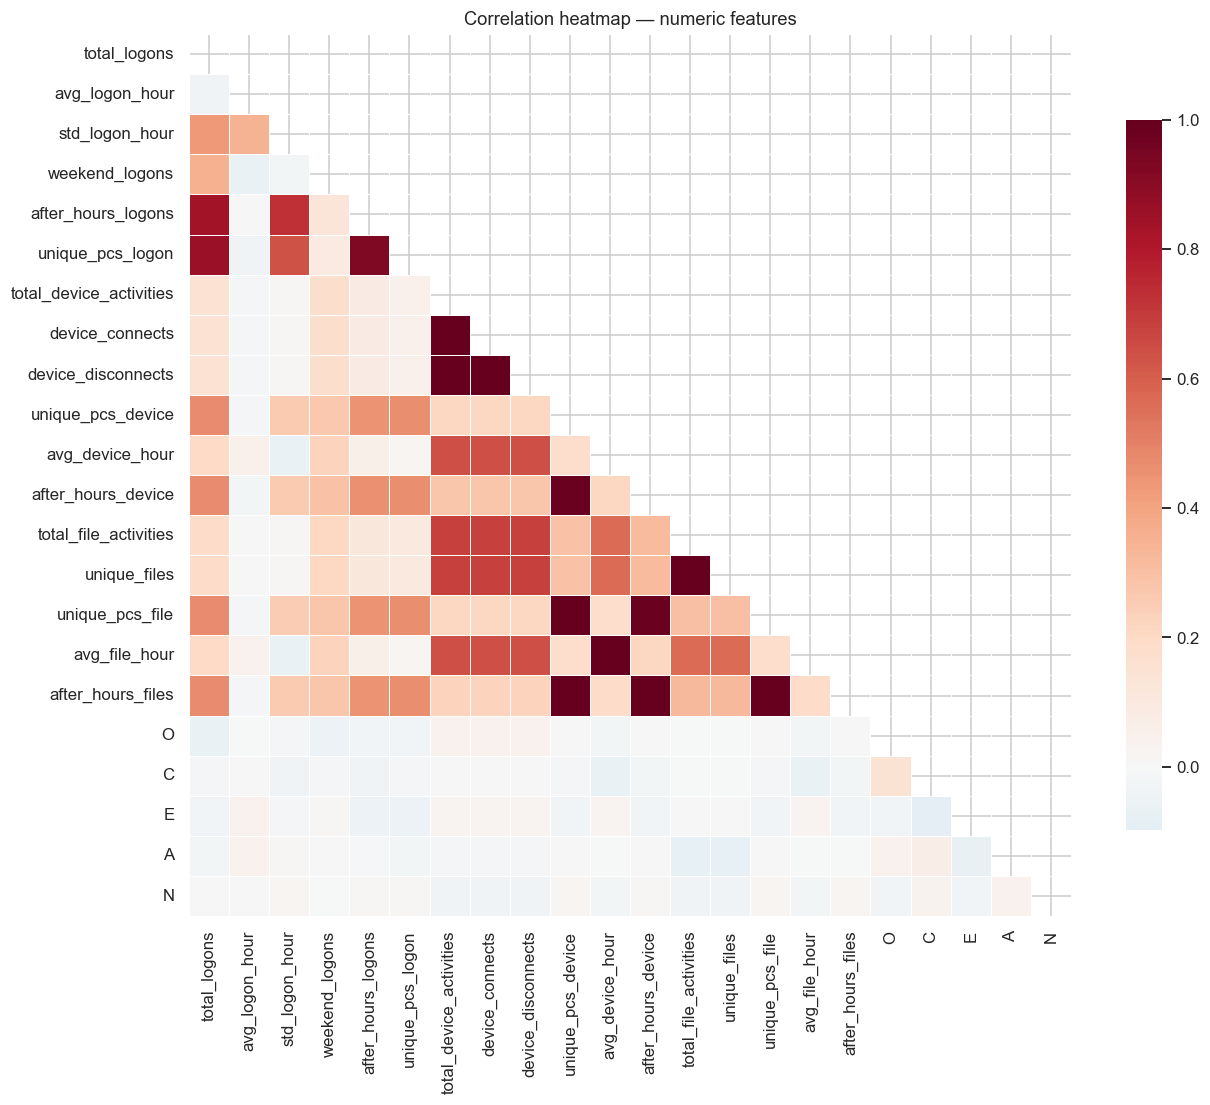

In [25]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation heatmap — numeric features')
plt.tight_layout()
plt.show()


The heatmap shows three coherent blocks — logon-timing features, device features, and file features — that correlate within block but weakly across blocks, while psychometric traits are essentially uncorrelated with behaviour.

## Distributions

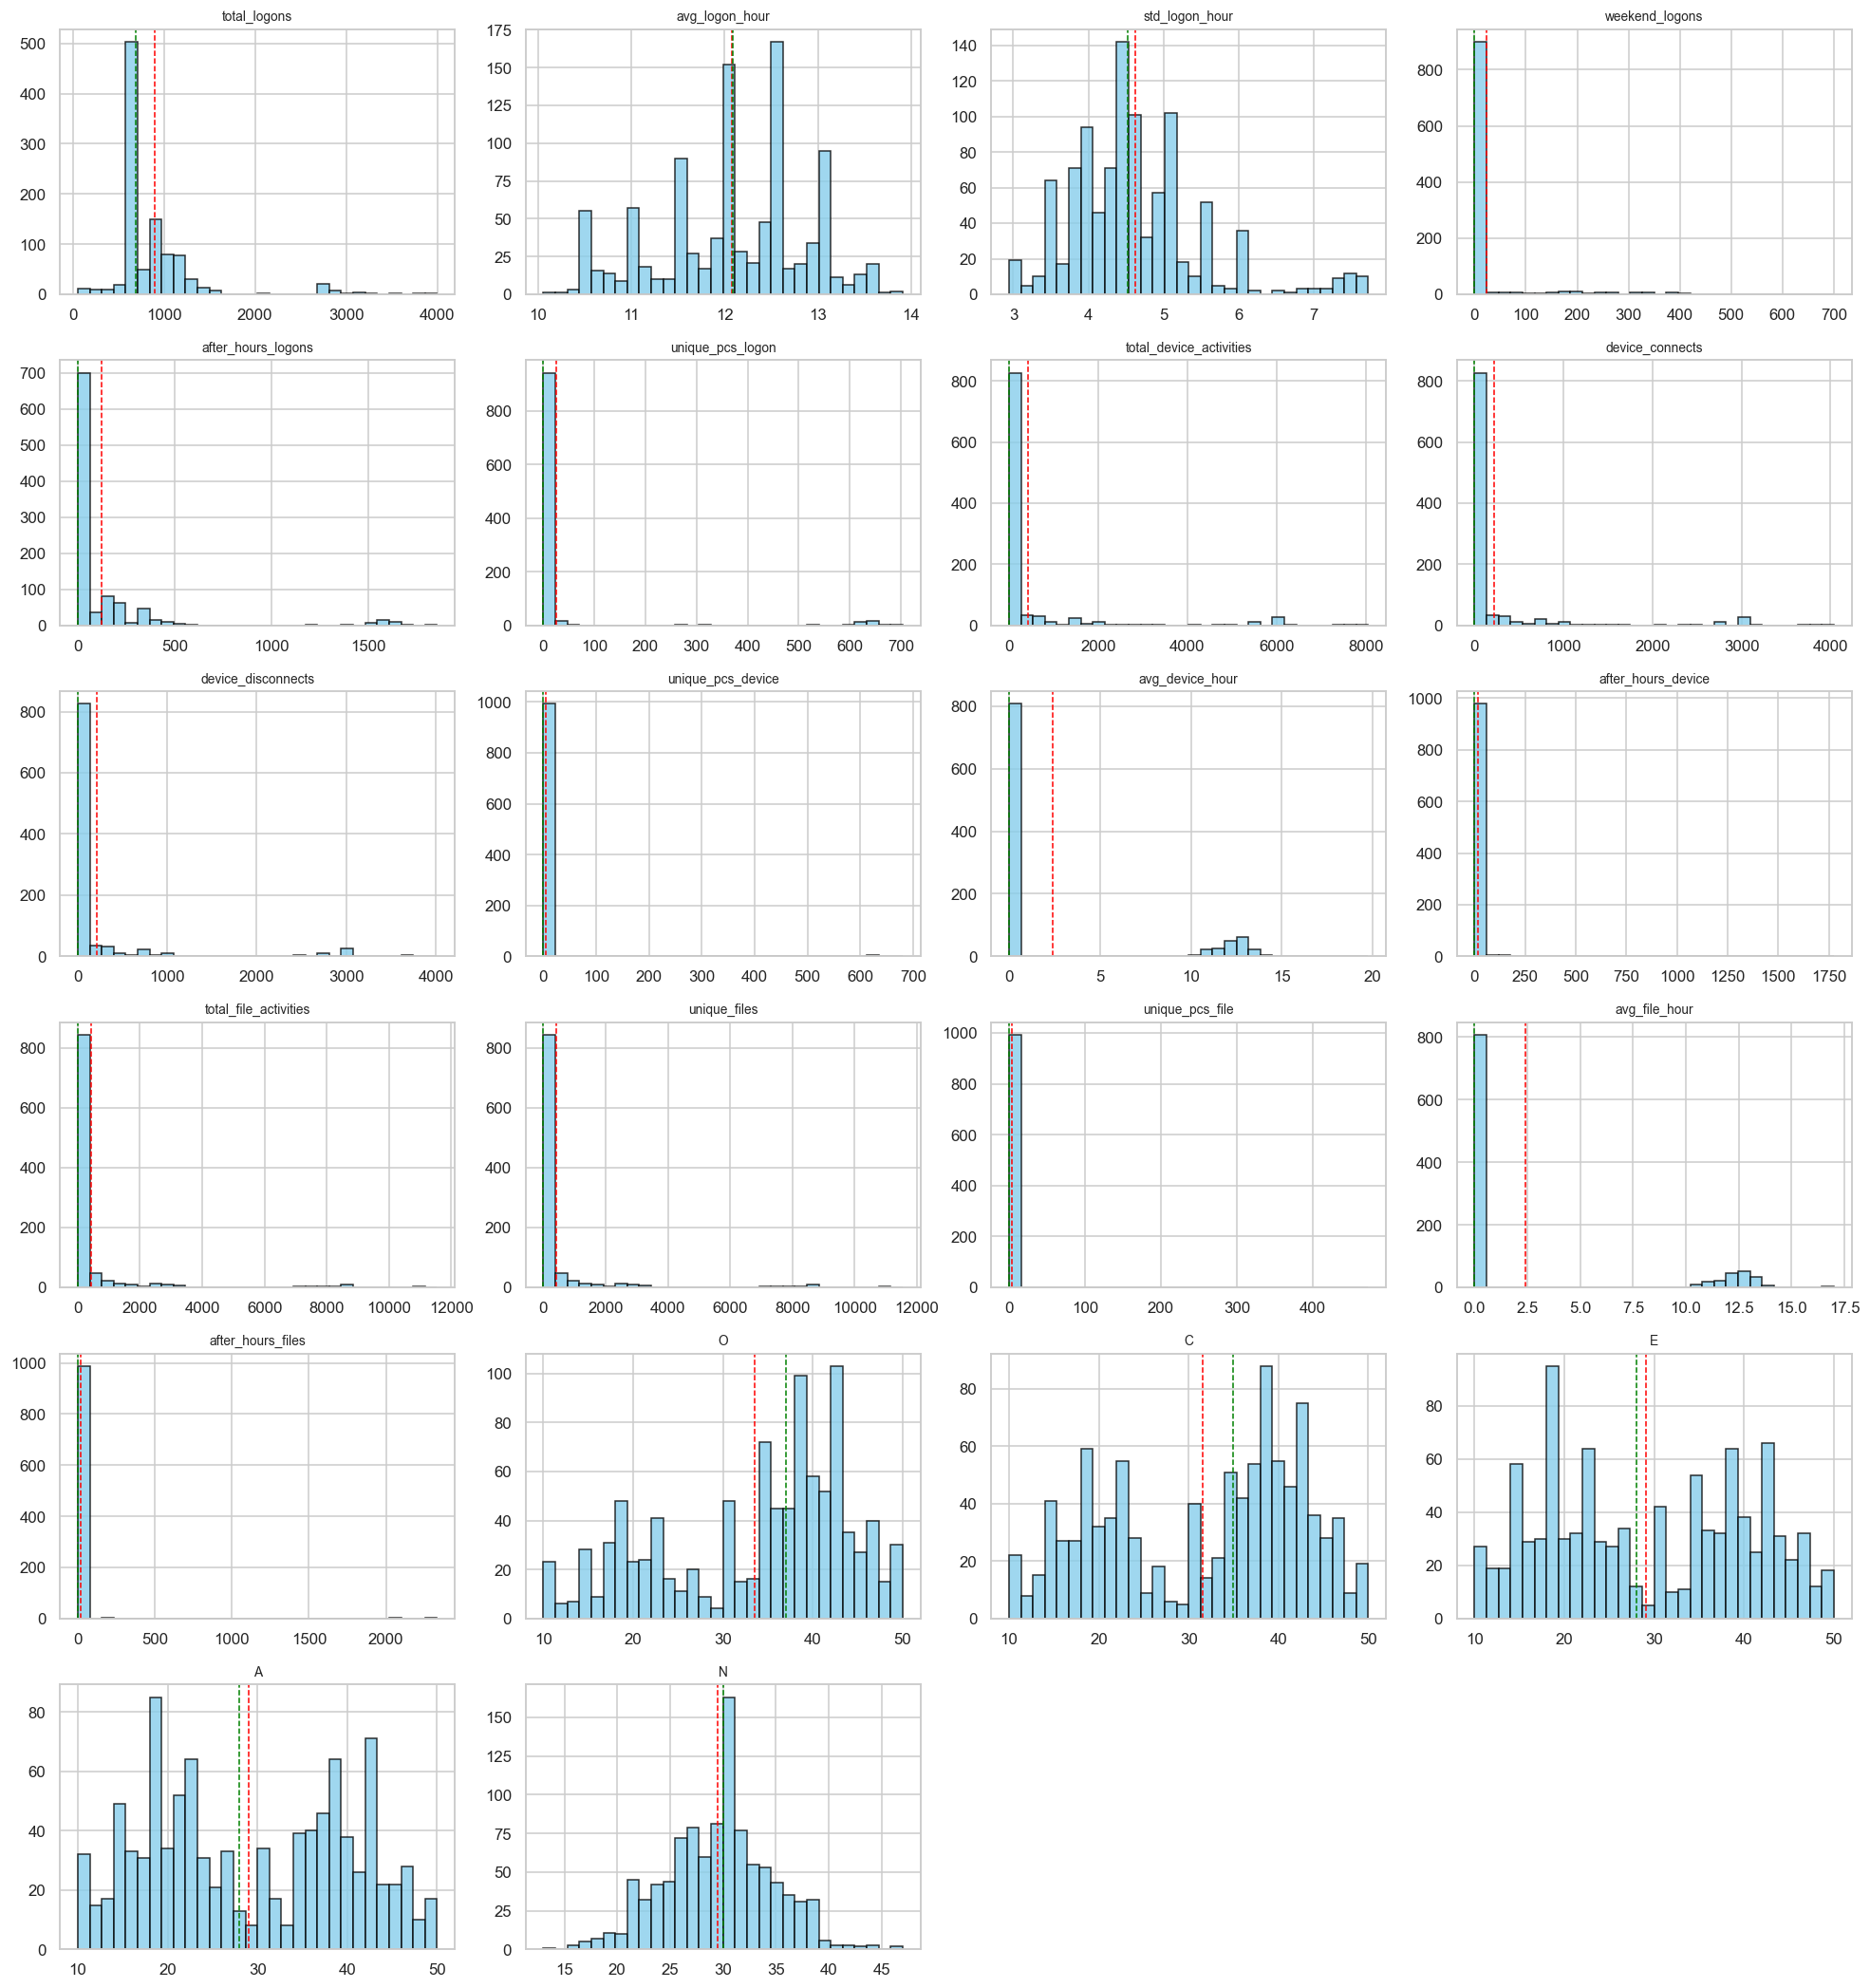

In [26]:
n = len(numerical_cols)
ncol = 4
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(18, 3.2 * nrow))
for ax, col in zip(axes.ravel(), numerical_cols):
    ax.hist(features[col], bins=30, color='skyblue', edgecolor='black', alpha=0.8)
    ax.axvline(features[col].mean(), color='red', ls='--', lw=1)
    ax.axvline(features[col].median(), color='green', ls='--', lw=1)
    ax.set_title(col, fontsize=9)
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


Red (mean) sits well to the right of green (median) for nearly every count feature, the visual signature of right skew. Many device/file features are zero-inflated — a tall bar at zero plus a thin tail. Psychometric histograms are broad and roughly uniform. The zero-inflation plus tails is why simple z-score thresholds would misbehave.

## Outlier scan (IQR method)

Before modelling, Quantifying how many points each feature flags as an outlier under the standard 1.5×IQR rule. This is a sanity check on the 'thin tail' impression from the histograms.

In [27]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((s < lo) | (s > hi)).sum()
    return pd.Series({'n_outliers': n, 'pct': 100 * n / len(s), 'lower': lo, 'upper': hi})

outlier_summary = features[numerical_cols].apply(iqr_outliers).T
outlier_summary.sort_values('n_outliers', ascending=False).round(2)


,n_outliers,pct,lower,upper
unique_files,193.0,19.3,0.00,0.00
avg_file_hour,193.0,19.3,0.00,0.00
total_device_activities,193.0,19.3,0.00,0.00
device_connects,193.0,19.3,0.00,0.00
device_disconnects,193.0,19.3,0.00,0.00
unique_pcs_device,193.0,19.3,0.00,0.00
avg_device_hour,193.0,19.3,0.00,0.00
unique_pcs_file,193.0,19.3,0.00,0.00
total_file_activities,193.0,19.3,0.00,0.00
weekend_logons,179.0,17.9,0.00,0.00


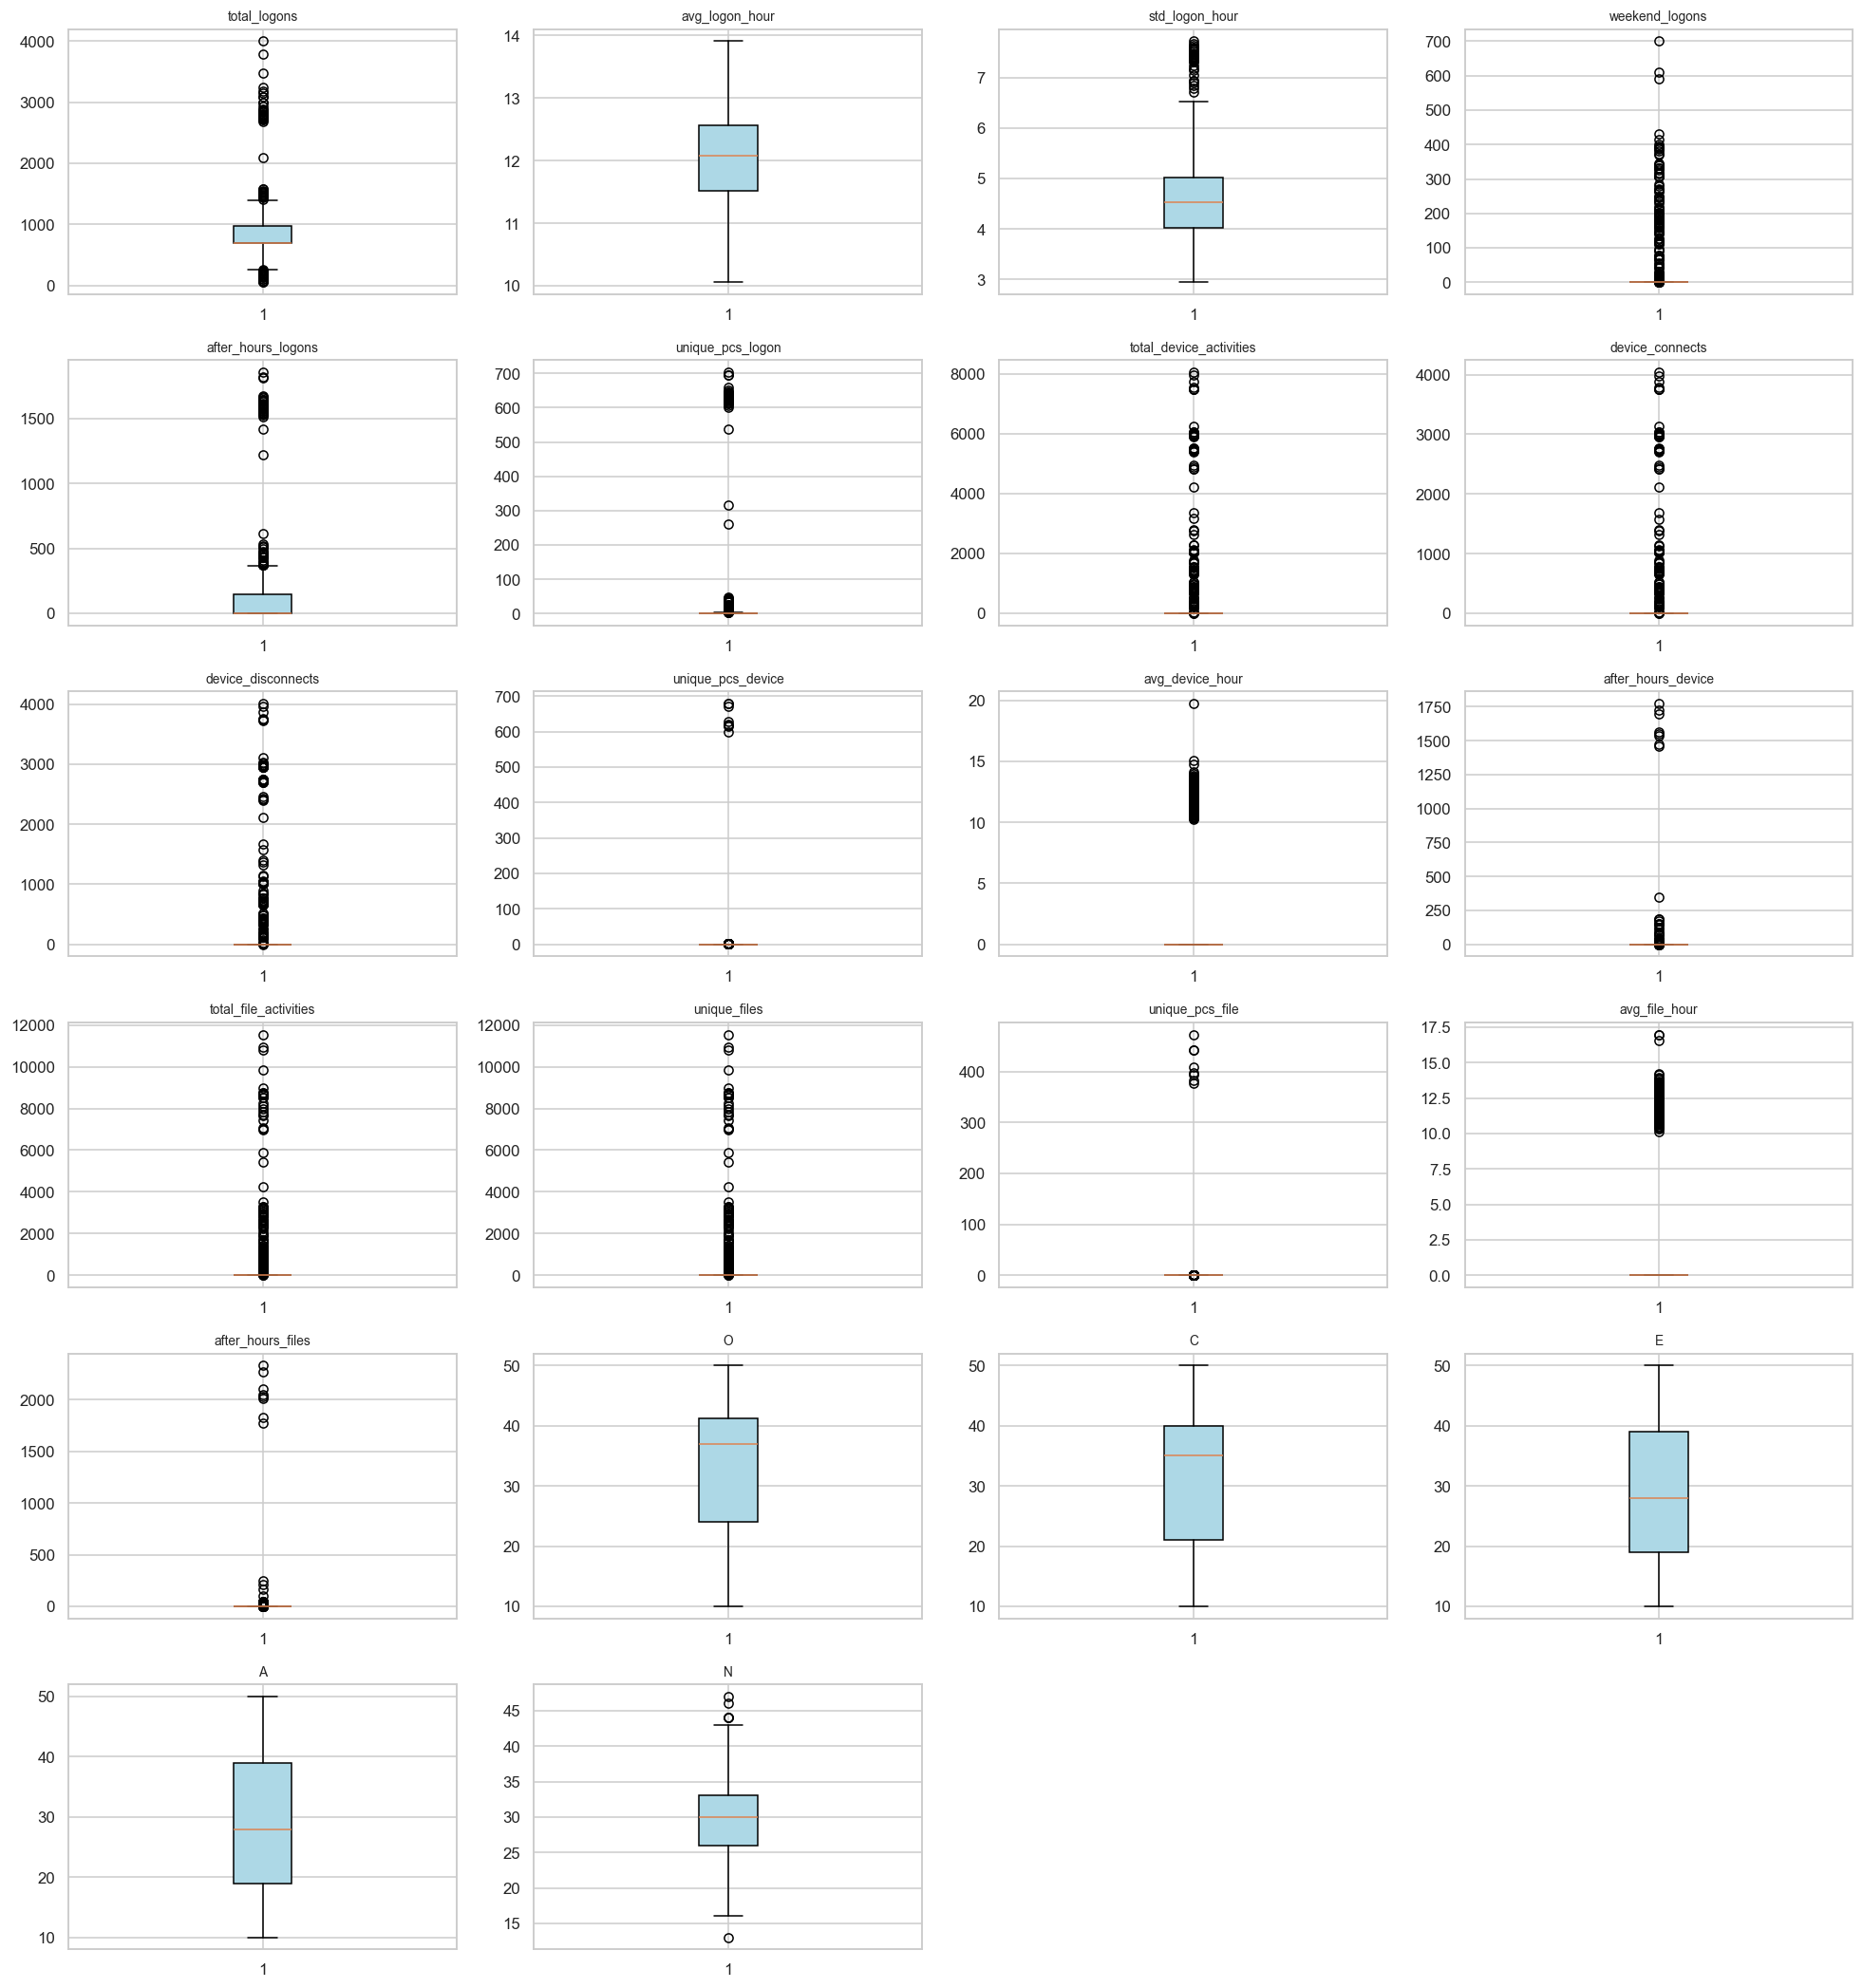

In [28]:
fig, axes = plt.subplots(int(np.ceil(len(numerical_cols) / 4)), 4, figsize=(18, 3.2 * int(np.ceil(len(numerical_cols) / 4))))
for ax, col in zip(axes.ravel(), numerical_cols):
    ax.boxplot(features[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col, fontsize=9)
for ax in axes.ravel()[len(numerical_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

For the zero-inflated device/file features the IQR is 0, so the rule flags ~19% of users (anyone with any activity) as 'outliers' — an artefact of the distribution, not a meaningful anomaly signal. This confirms univariate IQR rules are unsuitable here and justifies moving to multivariate, model-based detection (Isolation Forest / LOF).

## Data quality

In [29]:
features.isnull().sum().sum()

np.int64(0)

In [30]:
features.duplicated().sum()

np.int64(0)

In [31]:
completeness = 100 * features.notna().sum().sum() / features.size
round(completeness, 2)


np.float64(100.0)

No missing values (zeros are genuine 'no activity'), no duplicate rows.